# Integrating scRNA-seq with spatial data (Visium and Xenium)

**A companion vignette in the style of [The Xenium In Situ Gene Expression Data Analysis Workshop](https://www.10xgenomics.com/analysis-guides/workshop-xenium-in-situ-analysis)**, focused on **integrating an annotated scRNA-seq reference into spatial data**.

Spatial technologies measure gene expression in place, but not always at single-cell resolution, and rarely with the same depth of cell-type annotation a dedicated scRNA-seq reference has. Integration lets you borrow that annotation:

- **Visium** spots typically contain several to a few dozen cells each - so "integration" here means **deconvolution**: estimating what mixture of reference cell types makes up each spot.
- **Xenium** already resolves individual cells - so integration is closer to **label transfer**: assigning each already-segmented cell the reference cell type it most resembles.

We cover two methods for both problems:

- **`scanpy.tl.ingest`** - a fast, dependency-light baseline built into scanpy, giving each spot/cell a single best-matching label.
- **[Tangram](https://github.com/broadinstitute/Tangram)** (`tangram-sc`) - a purpose-built deep-learning method from the Broad Institute for exactly this task, which can produce full cell-type *proportions* per spot (not just one dominant label) and generally maps more accurately.

Both parts use a **biologically matched** scRNA-seq reference - not a generic PBMC dataset - since a mismatched reference is one of the most common ways this kind of analysis goes wrong.

How to use this Google Colab

- Select Python as the programming language: Click "Runtime -> Change runtime type", then ensure "Runtime type" is set to "Python". Tangram benefits from a GPU runtime if available, but runs on CPU too (just slower) - either works for the small samples here.
- Click the "Connect" button on the top-right corner. Now, you are ready to run the tutorial.

# **1. Install and import packages**

In [1]:
# Install required python packages (takes ~2-3 min)
!uv pip install scanpy==1.11.2 squidpy==1.6.5 spatialdata==0.4.0 spatialdata-io==0.3.0 spatialdata-plot tangram-sc==1.0.4 igraph==0.11.8 leidenalg==0.10.2 datashader==0.18.2 distributed

# import the python packages
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tangram as tg
import warnings
import gc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

Using Python 3.13.15 environment at: /usr
Resolved 142 packages in 5.81s
Prepared 50 packages in 3.58s
Uninstalled 4 packages in 47ms
Installed 50 packages in 129ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + anndata==0.12.19
 + array-api-compat==1.15.0
 + asciitree==0.3.3
 + botocore==1.41.5
 - dask==2026.8.0
 + dask==2024.11.2
 + dask-image==2026.5.0
 + datashader==0.18.2
 + deprecated==3.0.0
 - distributed==2026.8.0
 + distributed==2024.11.2
 + docrep==0.3.2
 + fasteners==0.20
 + flowio==1.4.0
 + igraph==0.11.8
 + imagecodecs==2026.8.16
 + jmespath==1.1.0
 + legacy-api-wrap==1.5
 + leidenalg==0.10.2
 + matplotlib-scalebar==0.9.0
 + multiscale-spatial-image==2.0.3
 + numcodecs==0.15.1
 + ome-types==0.6.3
 + ome-zarr==0.11.1
 + omnipath==1.0.12
 + pims==0.7
 + pyct==0.6.0
 + pydantic-extra-types==2.11.1
 + readfcs==2.1.0
 + s3fs==2025.12.0
 + scanpy==1.11.2
 + scverse-misc==0.1.6
 + session-info2==0.4.2
 + slicerator==1.1.0
 + spatial-image==1.2.3
 + spatialdata==0.4.0
 + spatia

/usr/local/lib/python3.13/dist-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.13/dist-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/usr/local/lib/python3.13/dist-packages/leidenalg/VertexPartition.py:788: SyntaxWarn

# **2. Part A: Deconvolving Visium spots (human lymph node)**

## 2.1 Load the Visium sample

The same public human lymph node sample used in the earlier notebooks in this series.

In [2]:
adata_st = sq.datasets.visium("V1_Human_Lymph_Node")
adata_st.var_names_make_unique()

sc.pp.calculate_qc_metrics(adata_st, inplace=True, percent_top=None)
sc.pp.filter_cells(adata_st, min_counts=500)
sc.pp.filter_genes(adata_st, min_cells=10)
adata_st.layers["counts"] = adata_st.X.copy()
sc.pp.normalize_total(adata_st)
sc.pp.log1p(adata_st)

  0%|          | 0.00/7.86M [00:00<?, ?B/s]

  0%|          | 0.00/29.3M [00:00<?, ?B/s]

## 2.2 A scRNA-seq reference: PBMC3k

We use the same small (~10 MB), scanpy-built-in **PBMC3k** dataset already used elsewhere in this series instead.

PBMC3k is blood, not lymph node tissue. The shared circulating immune populations (T cells, B cells, NK cells, monocytes) still overlap enough for a workable demo, but lymph-node-resident populations with no blood equivalent - germinal center B cells, follicular dendritic cells, lymphatic endothelium - simply are not in this reference, so Tangram/ingest have no way to ever assign a spot to them. Any spot genuinely dominated by one of those types will get mapped to whichever available cell type looks closest instead. A real deconvolution project should use a tissue-matched reference; see the note at the end of this notebook for where to find one.

PBMC3k also has no existing cell type annotation, so we derive one with the same marker-scoring approach used in the cell type annotation and figure-development notebooks in this series.

In [3]:
adata_ref = sc.datasets.pbmc3k()
adata_ref.var_names_make_unique()

sc.pp.filter_cells(adata_ref, min_genes=200)
sc.pp.filter_genes(adata_ref, min_cells=3)
adata_ref.layers["counts"] = adata_ref.X.copy()
sc.pp.normalize_total(adata_ref, target_sum=1e4)
sc.pp.log1p(adata_ref)
adata_ref.raw = adata_ref

# Restrict to genes also present in the Visium sample up front
shared_genes = adata_ref.var_names.intersection(adata_st.var_names)
print(f"{len(shared_genes)} genes shared between the reference and the Visium sample")
adata_ref = adata_ref[:, shared_genes].copy()

# Cluster the reference so we have groups to assign cell type labels to
adata_ref_clust = adata_ref.copy()
sc.pp.highly_variable_genes(adata_ref_clust, n_top_genes=2000)
adata_ref_clust = adata_ref_clust[:, adata_ref_clust.var.highly_variable].copy()
sc.pp.scale(adata_ref_clust, max_value=10)
sc.tl.pca(adata_ref_clust, n_comps=30)
sc.pp.neighbors(adata_ref_clust)
sc.tl.leiden(adata_ref_clust, flavor="igraph", n_iterations=-1, resolution=0.5)
adata_ref.obs["leiden"] = adata_ref_clust.obs["leiden"].values

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

11590 genes shared between the reference and the Visium sample


Score each cluster against canonical PBMC marker genes and assign whichever cell type scores highest - the same pattern used for manual annotation earlier in this series.

In [4]:
pbmc_marker_genes = {
    "CD4 T cells": ["IL7R", "CD3D", "CD3E"],
    "CD8 T cells": ["CD8A", "CD8B", "CD3D"],
    "B cells": ["MS4A1", "CD79A", "CD79B"],
    "NK cells": ["GNLY", "NKG7", "KLRD1"],
    "CD14+ Monocytes": ["CD14", "LYZ", "S100A8"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Megakaryocytes": ["PPBP", "PF4"],
}

for name, genes in pbmc_marker_genes.items():
    genes_present = [g for g in genes if g in adata_ref.var_names]
    sc.tl.score_genes(adata_ref, genes_present, score_name=f"score_{name}")

score_cols = [f"score_{name}" for name in pbmc_marker_genes]
cluster_scores = adata_ref.obs.groupby("leiden")[score_cols].mean()
cluster_scores.columns = list(pbmc_marker_genes.keys())
best_type_per_cluster = cluster_scores.idxmax(axis=1)

adata_ref.obs["cell_type"] = adata_ref.obs["leiden"].map(best_type_per_cluster).astype("category")
CELLTYPE_COL = "cell_type"

del adata_ref_clust
gc.collect()

52474

## 2.3 A fast baseline: label transfer with `sc.tl.ingest`

`sc.tl.ingest` projects a query dataset (the Visium spots) into a reference's existing PCA/neighbor space, then assigns each query observation the label of its nearest reference neighbors. It gives every spot exactly **one** dominant label - a reasonable fast baseline, but not a true deconvolution, since real spots are mixtures.

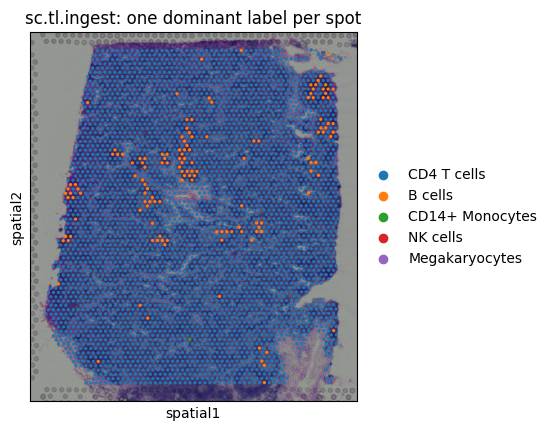

In [5]:
sc.pp.highly_variable_genes(adata_ref, n_top_genes=2000, batch_key=None)
hvg_genes = adata_ref.var_names[adata_ref.var.highly_variable]

# sc.tl.ingest requires the query and reference to have the EXACT same variables in the
# same order (it errors otherwise) - .intersection() would not guarantee that ordering,
# so we build one explicit shared, ordered gene list and slice both objects to it.
shared_hvg = [g for g in hvg_genes if g in adata_st.var_names]

adata_ref_hvg = adata_ref[:, shared_hvg].copy()
sc.pp.pca(adata_ref_hvg, n_comps=30)
sc.pp.neighbors(adata_ref_hvg)
sc.tl.umap(adata_ref_hvg)

adata_st_hvg = adata_st[:, shared_hvg].copy()

sc.tl.ingest(adata_st_hvg, adata_ref_hvg, obs=CELLTYPE_COL)
adata_st.obs["ingest_cell_type"] = adata_st_hvg.obs[CELLTYPE_COL].values

sc.pl.spatial(adata_st, color="ingest_cell_type", title="sc.tl.ingest: one dominant label per spot")

## 2.4 A proper deconvolution: Tangram

Tangram learns a mapping between reference cells and spatial spots that best reproduces the spatial data's own expression pattern, then lets us read off, for every spot, what *proportion* of it is made up of each reference cell type - closer to what a Visium spot actually is (a mixture), rather than forcing one label per spot. Optimizing over every shared gene (several thousand here) makes each training epoch far slower than it needs to be for little added benefit - Tangram's own tutorials train on a few hundred to ~1,200 marker genes instead, so we do the same: take each cell type's top marker genes rather than the full shared gene set.

In [6]:
sc.tl.rank_genes_groups(adata_ref, groupby=CELLTYPE_COL, method="wilcoxon")
marker_df = sc.get.rank_genes_groups_df(adata_ref, group=None)
tangram_genes = marker_df.groupby("group").head(50)["names"].unique().tolist()
print(f"Using {len(tangram_genes)} marker genes for Tangram (out of {len(shared_genes)} shared genes)")

tg.pp_adatas(adata_ref, adata_st, genes=tangram_genes)

Using 231 marker genes for Tangram (out of 11590 shared genes)


INFO:root:221 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:11590 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [7]:
# mode="clusters" maps reference CELL TYPES (not individual reference cells) onto the spots -
# a good default whenever the reference is much larger than the number of spatial spots, or
# (as here) there is no per-spot nucleus count available for Tangram's "constrained" mode.
# A few hundred marker genes (2.4's setup) converges in well under 200 epochs.
ad_map = tg.map_cells_to_space(
    adata_ref,
    adata_st,
    mode="clusters",
    cluster_label=CELLTYPE_COL,
    num_epochs=200,
    device="cpu",
)

INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 221 genes and rna_count_based density_prior in clusters mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.675, KL reg: 0.186
Score: 0.877, KL reg: 0.000


INFO:root:Saving results..


In [8]:
tg.project_cell_annotations(ad_map, adata_st, annotation=CELLTYPE_COL)

# Each column of this DataFrame is one cell type's predicted proportion in every spot
cell_type_proportions = adata_st.obsm["tangram_ct_pred"]
cell_type_proportions.head()

INFO:root:spatial prediction dataframe is saved in `obsm` `tangram_ct_pred` of the spatial AnnData.


,CD4 T cells,CD14+ Monocytes,NK cells,B cells,Megakaryocytes
AAACAAGTATCTCCCA-1,0.000207,0.000257,0.000308,0.000241,0.000587
AAACAATCTACTAGCA-1,0.000412,0.000193,0.000102,0.000100,0.000211
AAACACCAATAACTGC-1,0.000157,0.000343,0.000479,0.000244,0.000108
AAACAGAGCGACTCCT-1,0.000335,0.000191,0.000299,0.000220,0.000215
AAACAGCTTTCAGAAG-1,0.000267,0.000199,0.000159,0.000389,0.000180


## 2.5 Visualize and compare

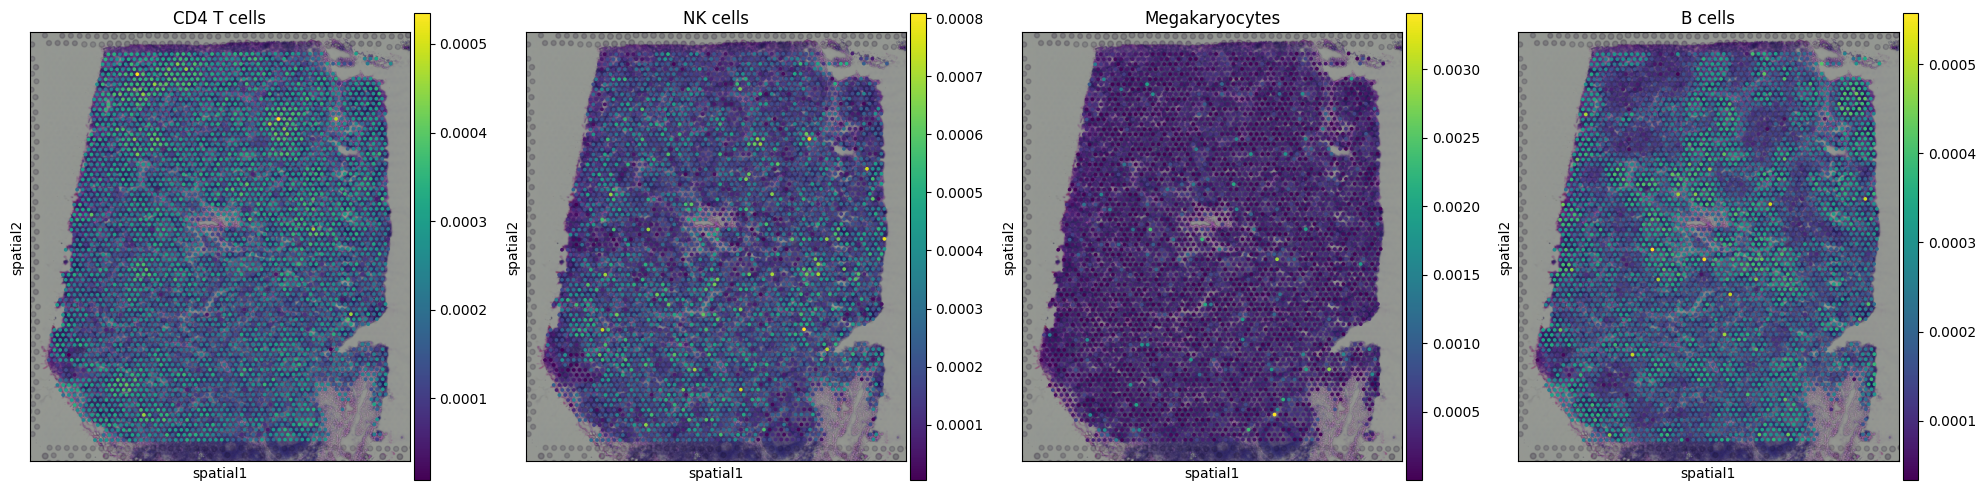

In [9]:
top_cell_types = cell_type_proportions.mean().sort_values(ascending=False).head(4).index.tolist()

for col in top_cell_types:
    adata_st.obs[col] = cell_type_proportions[col].values

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, cell_type in zip(axes, top_cell_types):
    sc.pl.spatial(adata_st, color=cell_type, ax=ax, show=False, title=cell_type, cmap="viridis")
plt.tight_layout()

In [10]:
# Tangram's own dominant cell type per spot (argmax of the proportions), for a direct
# comparison against the single-label ingest result from 2.3
adata_st.obs["tangram_dominant_cell_type"] = cell_type_proportions.idxmax(axis=1).values
pd.crosstab(adata_st.obs["ingest_cell_type"], adata_st.obs["tangram_dominant_cell_type"])

tangram_dominant_cell_type,B cells,CD14+ Monocytes,CD4 T cells,Megakaryocytes,NK cells
ingest_cell_type,,,,,
CD4 T cells,664,526,678,954,1063
B cells,93,0,3,41,2
CD14+ Monocytes,0,1,0,0,0


Where the two disagree, it's often a spot Tangram scored as a fairly even mixture of two or three types - exactly the situation a single-label method like `ingest` has no way to represent, but the proportions from 2.4 do.

In [11]:
del adata_ref, adata_ref_hvg, adata_st_hvg
gc.collect()

34544

# **3. Wrap-up**

The right integration approach depends on what the spatial data's own resolution already gives you: Visium spots mix several cells together, so the honest answer is a set of per-spot *proportions* (Tangram's `mode="clusters"`), not a single label. Xenium cells are already individually resolved, so integration is closer to a direct label transfer or nearest-match problem (Tangram's `mode="cells"`, or the faster `sc.tl.ingest` baseline). In both cases, the result is only as good as the reference: it needs to actually be drawn from a biologically comparable tissue, and needs enough gene overlap with the spatial panel to work with in the first place.

Part A used PBMC3k for size reasons, not because it's the right reference for lymph node tissue - a real project should use something like [Cell2location's own integrated lymph node/spleen/tonsil reference](https://cell2location.cog.sanger.ac.uk/paper/integrated_lymphoid_organ_scrna/RegressionNBV4Torch_57covariates_73260cells_10237genes/sc.h5ad) (~700 MB, downloadable the same way with `sc.read(..., backup_url=..., backed="r")` if your runtime can handle it) instead.

For further reading: [the Tangram paper](https://www.nature.com/articles/s41592-021-01358-2), [Tangram's documentation](https://tangram-sc.readthedocs.io/), and [Cell2location's lymph node deconvolution tutorial](https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_tutorial.html).